# 01 Developmental Tempo And Noise

Reads only from the centralized cache in `/Users/nick/Projects/data/morphseq/results/20260528`.


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from figure_utils import (
    BOOTSTRAP_SEED,
    CACHE_DIR,
    FIG_DIR,
    EXCLUDED_TEMPERATURES,
    add_identity,
    bootstrap_mean_se,
    drop_excluded_temperatures,
    is_included_temperature,
    plot_heatmap_matrix,
    plot_temperature_variability_bootstrap,
    savefig,
    set_light_style,
    temperature_timepoint_scatter,
    timepoint_average_variability_bootstrap,
    value_timepoint_scatter,
)
set_light_style()
print(CACHE_DIR)
print(FIG_DIR)


/Users/nick/Projects/data/morphseq/results/20260528
/Users/nick/Projects/data/morphseq/results/20260528/figures_no19C_timepoint


In [2]:

joint = drop_excluded_temperatures(pd.read_csv(CACHE_DIR / 'joint_141_morph_seq.csv'))
hf_morph = drop_excluded_temperatures(pd.read_csv(CACHE_DIR / 'hf_pca_morph_df_with_spline_distance.csv'))
manifest = pd.read_csv(CACHE_DIR / 'source_manifest.csv')
print(f'Excluded temperatures: {EXCLUDED_TEMPERATURES}')
print(joint.shape)
joint.head()


Excluded temperatures: (19.0,)
(117, 40)


,snip_id,temperature,timepoint,mdl_stage_hpf,pseudostage,PCA_00_bio_mean,PCA_00_bio_std,PCA_00_bio_count,PCA_01_bio_mean,PCA_01_bio_std,...,PCA_08_bio_std,PCA_08_bio_count,PCA_09_bio_mean,PCA_09_bio_std,PCA_09_bio_count,embryo_id,sample,morph_dist_spline,morph_branch_flag,nn_stage_hpf
1,20240813_24hpf_A03_e00_t0000,25.0,24.0,16.678449,23.207207,1.981657,0.147383,42,-0.751075,0.135772,...,0.042360,42,-0.004364,0.037301,42,20240813_24hpf_A03_e00_t0000,hotfish2_P05_A2,0.579035,False,17.768315
2,20240813_24hpf_A04_e00_t0000,28.5,24.0,24.137157,25.819820,-0.734977,0.242611,45,-1.613671,0.158663,...,0.046099,45,-0.078740,0.036958,45,20240813_24hpf_A04_e00_t0000,hotfish2_P05_A3,0.232631,False,25.925120
3,20240813_24hpf_A05_e00_t0000,32.0,24.0,28.506869,29.153153,-1.722967,0.165611,43,-1.262145,0.251711,...,0.034053,43,0.051215,0.034167,43,20240813_24hpf_A05_e00_t0000,hotfish2_P05_A4,0.254436,False,29.388246
4,20240813_24hpf_A06_e00_t0000,33.5,24.0,24.187232,26.630631,-1.490460,0.193664,54,-1.388786,0.189838,...,0.048336,54,-0.005558,0.050310,54,20240813_24hpf_A06_e00_t0000,hotfish2_P05_A5,0.392497,False,25.039300
5,20240813_24hpf_A07_e00_t0000,35.0,24.0,23.675303,31.765765,-0.399626,0.203910,46,-0.849709,0.286624,...,0.064834,46,0.121007,0.064447,46,20240813_24hpf_A07_e00_t0000,hotfish2_P05_A6,1.060592,True,23.249860


## 1.a Sequence-based stage predictions vs morphology-based stage predictions


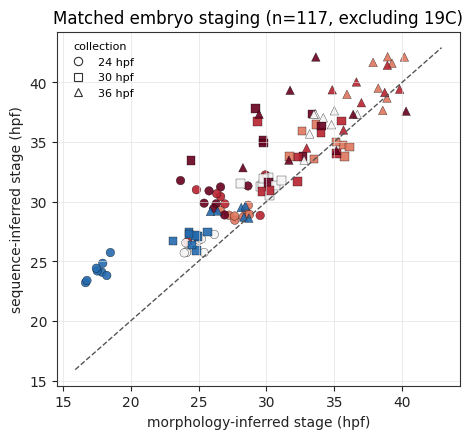

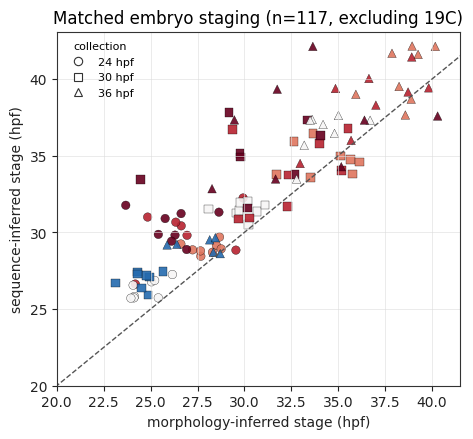

In [3]:

fig, ax = plt.subplots(figsize=(5.2, 4.6))
temperature_timepoint_scatter(
    ax,
    joint['mdl_stage_hpf'],
    joint['pseudostage'],
    joint['temperature'],
    joint['timepoint'],
    s=38,
    alpha=0.9,
)
add_identity(ax, joint['mdl_stage_hpf'], joint['pseudostage'])
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('sequence-inferred stage (hpf)')
ax.set_title(f'Matched embryo staging (n={len(joint)}, excluding 19C)')
savefig(fig, '01a_seq_vs_morph_stage')
plt.show()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
temperature_timepoint_scatter(
    ax,
    joint['mdl_stage_hpf'],
    joint['pseudostage'],
    joint['temperature'],
    joint['timepoint'],
    s=38,
    alpha=0.9,
)
ax.set_xlim(left=20)
ax.set_ylim(bottom=20)
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('sequence-inferred stage (hpf)')
ax.set_title(f'Matched embryo staging (n={len(joint)}, excluding 19C)')
savefig(fig, '01a_seq_vs_morph_stage_min20_axes')
plt.show()


### Temperature-stage group averages

Matched embryo staging summarized by temperature x collection timepoint.


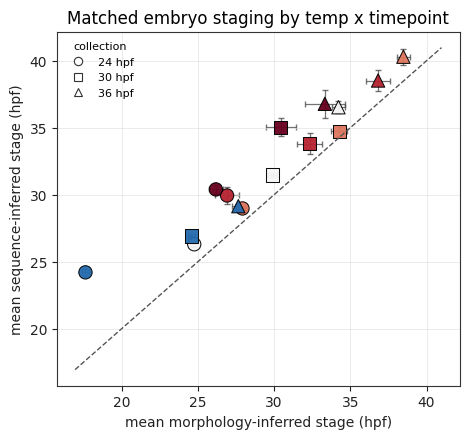

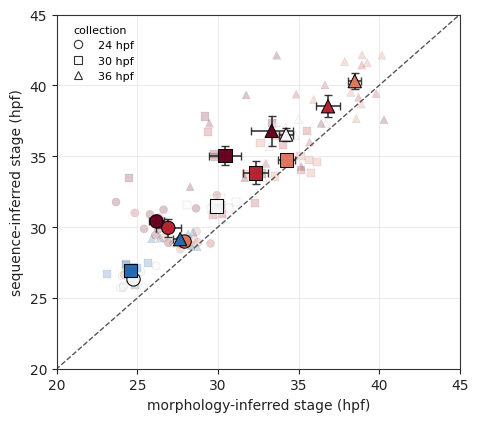

,temperature,timepoint,morph_stage_mean,morph_stage_mean_boot_se,seq_stage_mean,seq_stage_mean_boot_se,n
0,25.0,24.0,17.628057,0.213015,24.206832,0.265501,8
1,25.0,30.0,24.569938,0.240202,26.919745,0.179607,8
2,25.0,36.0,27.655813,0.447088,29.146812,0.156331,6
3,28.5,24.0,24.761971,0.270577,26.304693,0.207981,8
4,28.5,30.0,29.910695,0.293097,31.478885,0.156967,8
5,28.5,36.0,34.222927,0.419576,36.530674,0.458935,8
6,32.0,24.0,27.928058,0.252122,28.976854,0.127349,8
7,32.0,30.0,34.271651,0.531147,34.727658,0.345452,8
8,32.0,36.0,38.484194,0.405393,40.300950,0.585227,8
9,33.5,24.0,26.917205,0.760750,29.944082,0.623916,7


In [4]:

rng = np.random.default_rng(BOOTSTRAP_SEED)
stage_rows = []
for (temperature, timepoint), group in joint.groupby(['temperature', 'timepoint'], sort=True):
    stage_rows.append(
        {
            'temperature': temperature,
            'timepoint': timepoint,
            'morph_stage_mean': group['mdl_stage_hpf'].mean(),
            'morph_stage_mean_boot_se': bootstrap_mean_se(group['mdl_stage_hpf'], rng),
            'seq_stage_mean': group['pseudostage'].mean(),
            'seq_stage_mean_boot_se': bootstrap_mean_se(group['pseudostage'], rng),
            'n': group['snip_id'].count(),
        }
    )
stage_group = pd.DataFrame(stage_rows)
stage_group.to_csv(CACHE_DIR / 'seq_vs_morph_stage_group_means_no19C.csv', index=False)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.errorbar(
    stage_group['morph_stage_mean'],
    stage_group['seq_stage_mean'],
    xerr=stage_group['morph_stage_mean_boot_se'],
    yerr=stage_group['seq_stage_mean_boot_se'],
    fmt='none',
    ecolor='#444444',
    elinewidth=0.9,
    capsize=2.5,
    alpha=0.75,
    zorder=1,
)
temperature_timepoint_scatter(
    ax,
    stage_group['morph_stage_mean'],
    stage_group['seq_stage_mean'],
    stage_group['temperature'],
    stage_group['timepoint'],
    s=92,
    alpha=0.95,
    linewidth=0.75,
    zorder=2,
)
add_identity(ax, stage_group['morph_stage_mean'], stage_group['seq_stage_mean'])
ax.set_xlabel('mean morphology-inferred stage (hpf)')
ax.set_ylabel('mean sequence-inferred stage (hpf)')
ax.set_title('Matched embryo staging by temp x timepoint')
savefig(fig, '01a_seq_vs_morph_stage_group_means')
plt.show()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
temperature_timepoint_scatter(
    ax,
    joint['mdl_stage_hpf'],
    joint['pseudostage'],
    joint['temperature'],
    joint['timepoint'],
    s=34,
    alpha=0.22,
    linewidth=0.2,
    add_legend=False,
)
ax.errorbar(
    stage_group['morph_stage_mean'],
    stage_group['seq_stage_mean'],
    xerr=stage_group['morph_stage_mean_boot_se'],
    yerr=stage_group['seq_stage_mean_boot_se'],
    fmt='none',
    ecolor='#222222',
    elinewidth=1.2,
    capsize=3,
    alpha=0.9,
    zorder=3,
)
temperature_timepoint_scatter(
    ax,
    stage_group['morph_stage_mean'],
    stage_group['seq_stage_mean'],
    stage_group['temperature'],
    stage_group['timepoint'],
    s=92,
    alpha=0.98,
    linewidth=0.75,
    add_colorbar=False,
    zorder=4,
)
ax.set_xlim(20, 45)
ax.set_ylim(20, 45)
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('sequence-inferred stage (hpf)')
savefig(fig, '01a_seq_vs_morph_stage_individuals_and_group_means_min20_axes')
plt.show()
stage_group


## 1.b Staging variability comparison

Uses cohort-level standard deviations available from the old morphology and sequencing staging notebooks.


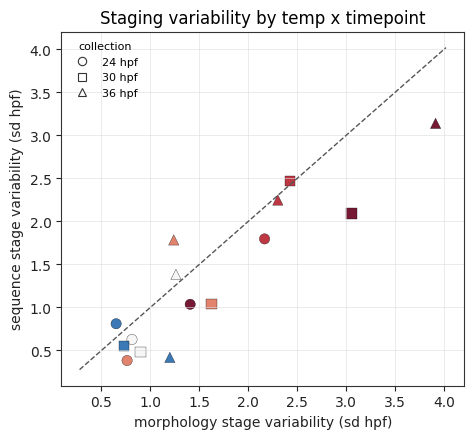

In [5]:

cohort = joint.groupby(['temperature', 'timepoint'], as_index=False).agg(
    morph_stage_mean=('mdl_stage_hpf', 'mean'),
    morph_stage_std=('mdl_stage_hpf', 'std'),
    seq_stage_mean=('pseudostage', 'mean'),
    seq_stage_std=('pseudostage', 'std'),
    n=('snip_id', 'count'),
)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
temperature_timepoint_scatter(
    ax,
    cohort['morph_stage_std'],
    cohort['seq_stage_std'],
    cohort['temperature'],
    cohort['timepoint'],
    s=55,
)
add_identity(ax, cohort['morph_stage_std'], cohort['seq_stage_std'])
ax.set_xlabel('morphology stage variability (sd hpf)')
ax.set_ylabel('sequence stage variability (sd hpf)')
ax.set_title('Staging variability by temp x timepoint')
savefig(fig, '01b_staging_variability_comparison')
plt.show()
cohort.to_csv(CACHE_DIR / 'tempo_noise_cohort_summary_no19C.csv', index=False)


### Bootstrap-SE variant

Bootstrap resampling within each temperature x timepoint cohort gives illustrative SE bars for the cohort SD estimates.


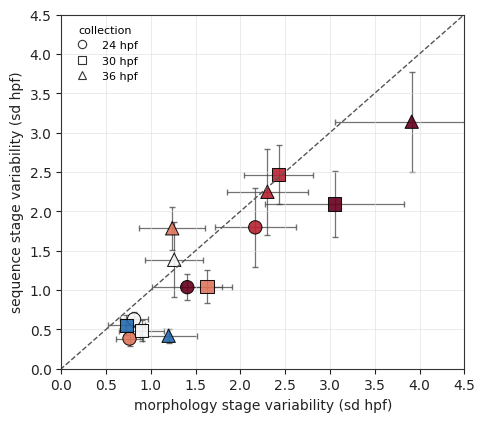

,temperature,timepoint,morph_stage_mean,morph_stage_std,morph_stage_std_boot_se,seq_stage_mean,seq_stage_std,seq_stage_std_boot_se,n,n_bootstrap,bootstrap_seed
0,25.0,24.0,17.628057,0.650013,0.125103,24.206832,0.810227,0.194541,8,5000,20260528
1,25.0,30.0,24.569938,0.727541,0.209026,26.919745,0.551112,0.126542,8,5000,20260528
2,25.0,36.0,27.655813,1.198820,0.315721,29.146812,0.418952,0.086606,6,5000,20260528
3,28.5,24.0,24.761971,0.812178,0.156815,26.304693,0.626979,0.095084,8,5000,20260528
4,28.5,30.0,29.910695,0.897429,0.254897,31.478885,0.484054,0.130115,8,5000,20260528
5,28.5,36.0,34.222927,1.261126,0.322397,36.530674,1.383651,0.478473,8,5000,20260528
6,32.0,24.0,27.928058,0.761984,0.154491,28.976854,0.382783,0.093809,8,5000,20260528
7,32.0,30.0,34.271651,1.625568,0.281658,34.727658,1.041594,0.208931,8,5000,20260528
8,32.0,36.0,38.484194,1.238693,0.370401,40.300950,1.784160,0.272177,8,5000,20260528
9,33.5,24.0,26.917205,2.166125,0.449496,29.944082,1.796007,0.502230,7,5000,20260528


In [6]:

from make_tempo_noise_bootstrap_se import build_bootstrap_summary

cohort_boot = build_bootstrap_summary(joint)
cohort_boot.to_csv(CACHE_DIR / 'tempo_noise_cohort_summary_bootstrap_se_no19C.csv', index=False)
cohort_boot_plot = cohort_boot.loc[
    ~((np.isclose(cohort_boot['temperature'], 25.0)) & (np.isclose(cohort_boot['timepoint'], 24.0))), :
].copy()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.errorbar(
    cohort_boot_plot['morph_stage_std'],
    cohort_boot_plot['seq_stage_std'],
    xerr=cohort_boot_plot['morph_stage_std_boot_se'],
    yerr=cohort_boot_plot['seq_stage_std_boot_se'],
    fmt='none',
    ecolor='#444444',
    elinewidth=0.9,
    capsize=2.5,
    alpha=0.75,
    zorder=1,
)
temperature_timepoint_scatter(
    ax,
    cohort_boot_plot['morph_stage_std'],
    cohort_boot_plot['seq_stage_std'],
    cohort_boot_plot['temperature'],
    cohort_boot_plot['timepoint'],
    s=92,
    linewidth=0.75,
    zorder=2,
)
ax.set_xlim(0, 4.5)
ax.set_ylim(0, 4.5)
add_identity(ax)
ax.set_xlabel('morphology stage variability (sd hpf)')
ax.set_ylabel('sequence stage variability (sd hpf)')
savefig(fig, '01b_staging_variability_comparison_bootstrap_se')
plt.show()
cohort_boot


## 1.c Deviations from Arrhenius predictions

Uses the prior linear Arrhenius-style expectation used in old notebooks: `6 + (timepoint - 6) * (0.055 * temperature - 0.57)`.


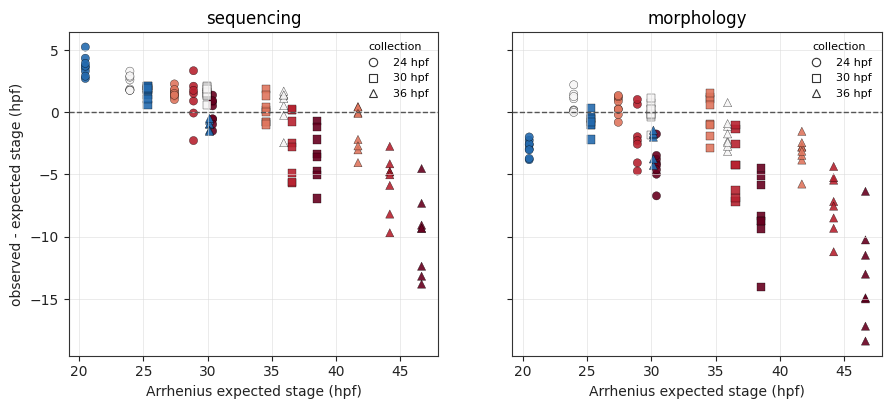

In [7]:

joint['arrhenius_expected_stage'] = 6 + (joint['timepoint'] - 6) * (0.055 * joint['temperature'] - 0.57)
joint['seq_arrhenius_dev'] = joint['pseudostage'] - joint['arrhenius_expected_stage']
joint['morph_arrhenius_dev'] = joint['mdl_stage_hpf'] - joint['arrhenius_expected_stage']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, y, title in zip(axes, ['seq_arrhenius_dev', 'morph_arrhenius_dev'], ['sequencing', 'morphology']):
    temperature_timepoint_scatter(
        ax,
        joint['arrhenius_expected_stage'],
        joint[y],
        joint['temperature'],
        joint['timepoint'],
        s=35,
        alpha=0.9,
    )
    ax.axhline(0, color='#555555', lw=1, ls='--')
    ax.set_xlabel('Arrhenius expected stage (hpf)')
    ax.set_title(title)
axes[0].set_ylabel('observed - expected stage (hpf)')
savefig(fig, '01c_arrhenius_deviations_seq_morph')
plt.show()


## 1.d Morphological variability as a function of temperature and stage


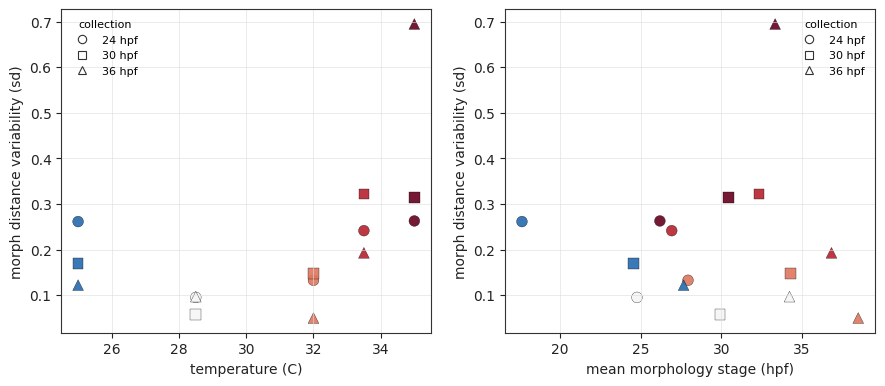

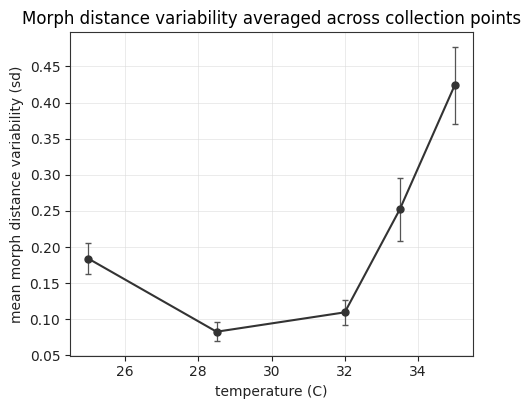

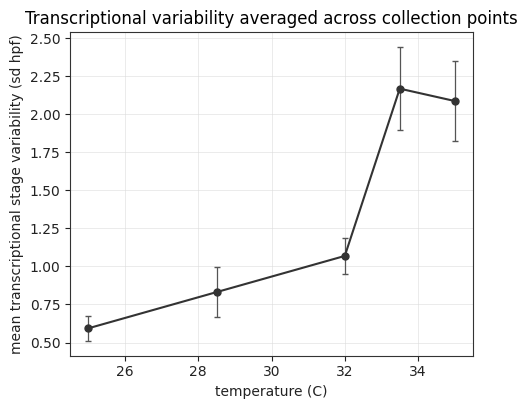

In [8]:

cohort_morph = hf_morph.groupby(['temperature', 'timepoint'], as_index=False).agg(
    morph_dist_spline_mean=('morph_dist_spline', 'mean'),
    morph_dist_spline_std=('morph_dist_spline', 'std'),
    morph_stage_mean=('mdl_stage_hpf', 'mean'),
    morph_stage_std=('mdl_stage_hpf', 'std'),
    n=('snip_id', 'count'),
)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
temperature_timepoint_scatter(
    axes[0],
    cohort_morph['temperature'],
    cohort_morph['morph_dist_spline_std'],
    cohort_morph['temperature'],
    cohort_morph['timepoint'],
    s=60,
)
axes[0].set_xlabel('temperature (C)')
axes[0].set_ylabel('morph distance variability (sd)')
temperature_timepoint_scatter(
    axes[1],
    cohort_morph['morph_stage_mean'],
    cohort_morph['morph_dist_spline_std'],
    cohort_morph['temperature'],
    cohort_morph['timepoint'],
    s=60,
)
axes[1].set_xlabel('mean morphology stage (hpf)')
axes[1].set_ylabel('morph distance variability (sd)')
savefig(fig, '01d_morph_variability_by_temperature_stage')
plt.show()
cohort_morph.to_csv(CACHE_DIR / 'morph_variability_cohort_summary_no19C.csv', index=False)

morph_temp_var = timepoint_average_variability_bootstrap(hf_morph, 'morph_dist_spline')
morph_temp_var.to_csv(CACHE_DIR / 'morph_distance_variability_temp_avg_bootstrap_se_no19C.csv', index=False)
fig, ax = plot_temperature_variability_bootstrap(
    morph_temp_var,
    'mean morph distance variability (sd)',
    'Morph distance variability averaged across collection points',
)
savefig(fig, '01e_morph_distance_variability_temp_avg_bootstrap_se')
plt.show()

seq_temp_var = timepoint_average_variability_bootstrap(joint, 'pseudostage')
seq_temp_var.to_csv(CACHE_DIR / 'transcriptional_stage_variability_temp_avg_bootstrap_se_no19C.csv', index=False)
fig, ax = plot_temperature_variability_bootstrap(
    seq_temp_var,
    'mean transcriptional stage variability (sd hpf)',
    'Transcriptional variability averaged across collection points',
)
savefig(fig, '01f_transcriptional_variability_temp_avg_bootstrap_se')
plt.show()
